# ДЗ №4. Подготовка датасета для ML-задачи мониторинга банковских рисков

Ноутбук объединяет код, таблицы, графики и выводы по финальному датасету `homework_04_dataset/data/dataset_for_training.csv`.

Основная ML-задача: бинарная классификация `alert_flag` по входу `title + text_fragment + entity_norm`.
Дополнительная разметка `risk_type_4cls` используется для анализа структуры рисков и будущей multi-class задачи.

## 1. Цель задачи

Продуктовая задача — выделять из новостного потока банковские риск-сигналы, которые стоит показать специалисту.

ML-задача текущего этапа — бинарная классификация:

```text
title + text_fragment + entity_norm -> alert_flag
```

`alert_flag = 1` означает, что фрагмент является риск-сигналом. `alert_flag = 0` означает, что банковское упоминание не требует карточки риска.

Основные метрики: precision, recall, F1 и PR-AUC. Accuracy не должна быть главной метрикой, потому что риск-события встречаются реже обычных банковских упоминаний.

In [2]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

RANDOM_SEED = 42
pd.set_option('display.max_colwidth', 160)

# Ноутбук должен запускаться из корня репозитория или из папки notebooks.
PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / 'homework_04_dataset' / 'data' / 'dataset_for_training.csv').exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError('Не найден homework_04_dataset/data/dataset_for_training.csv')

DATA_PATH = PROJECT_ROOT / 'homework_04_dataset' / 'data' / 'dataset_for_training.csv'
REPORT_DIR = PROJECT_ROOT / 'homework_04_dataset' / 'reports'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH, keep_default_na=False)
df.head()

,sample_id,event_group_id,split,text_fragment,title,entity_norm,found_risk_keywords,source,published_year,published_month,alert_flag,risk_type_4cls
0,ml_000001,eg_000001,train,"Газпромбанк и РСХБ самоустранились от проекта ""Едим дома!"" РСХБ и ГПБ заявили, что проект не соответствует их действующим кредитным программам. Росбанк (вхо...","Газпромбанк и РСХБ самоустранились от проекта ""Едим дома!""",Росбанк,,buriy,2015,5,0,no_risk
1,ml_000002,eg_000002,test,"Хакеры четыре года грабили клиентов Сбербанка и ВТБ Во время задержания хакеры попытались смыть в унитаз деньги, флешки и телефоны, а также хотели уничтожит...",Хакеры четыре года грабили клиентов Сбербанка и ВТБ,ВТБ,хакеры,buriy,2015,6,1,cyber_risk
2,ml_000003,eg_000003,train,"Exxon и ""Роснефть"" прекратили бурение в Арктике из-за санкций Вместе с тем страны ЕС расширили и индивидуальные ограничительные меры, добавив в санкционный ...","Exxon и ""Роснефть"" прекратили бурение в Арктике из-за санкций",Газпромбанк,санкции,buriy,2014,9,0,no_risk
3,ml_000004,eg_000004,valid,"Российские банки захотели оценивать расходы клиентов по картам при выдаче кредитов Проектом заинтересовались 15 российских банков, десять из которых «занима...",Российские банки захотели оценивать расходы клиентов по картам при выдаче кредитов,ВТБ,,telegram_contest,2019,11,0,no_risk
4,ml_000005,eg_000005,train,«Открытие» и «Росгосстрах» создадут крупнейшую частную финансовую группу Представители «Открытия» и «Росгосстраха» отказались от комментариев «Открытие» — о...,«Открытие» и «Росгосстрах» создадут крупнейшую частную финансовую группу,Банк Открытие,клиентская база,lenta,2016,12,0,no_risk


### Вывод

Датасет загружен из локальной папки задания, без абсолютных пользовательских путей. Это важно для воспроизводимости проверки.

ML-интерпретация: все дальнейшие проверки относятся к тому же файлу, который должен использоваться для обучения baseline-модели.

Риск: если ноутбук читает другой файл, выводы EDA могут не соответствовать финальному датасету.

Решение: использовать единый путь `homework_04_dataset/data/dataset_for_training.csv` и проверять его существование в начале ноутбука.

## 2. Источник и состав данных

Исходная база — RuNews / `IlyaGusev/ru_news`. Использовались русскоязычные новости. Единица наблюдения — один фрагмент новости вокруг упоминания банка. Одна новость может породить несколько строк, если в ней упоминаются разные банки.

Финальный датасет подготовлен для обучения модели бинарной классификации `alert_flag`.

In [3]:
column_roles = pd.DataFrame([
    {'column': 'sample_id', 'meaning': 'уникальный ID строки', 'feature': 'нет', 'target': 'нет', 'technical': 'да', 'leakage_risk': 'не использовать как feature'},
    {'column': 'event_group_id', 'meaning': 'группа одного или близкого инфоповода', 'feature': 'нет', 'target': 'нет', 'technical': 'да', 'leakage_risk': 'использовать только для split'},
    {'column': 'split', 'meaning': 'train/valid/test', 'feature': 'нет', 'target': 'нет', 'technical': 'да', 'leakage_risk': 'нельзя подавать в модель'},
    {'column': 'text_fragment', 'meaning': 'фрагмент новости вокруг банка', 'feature': 'да', 'target': 'нет', 'technical': 'нет', 'leakage_risk': 'низкий'},
    {'column': 'title', 'meaning': 'заголовок новости', 'feature': 'да', 'target': 'нет', 'technical': 'нет', 'leakage_risk': 'низкий'},
    {'column': 'entity_norm', 'meaning': 'нормализованный банк', 'feature': 'да, осторожно', 'target': 'нет', 'technical': 'нет', 'leakage_risk': 'может переобучить на банки'},
    {'column': 'found_risk_keywords', 'meaning': 'найденные риск-слова', 'feature': 'лучше нет для первой модели', 'target': 'нет', 'technical': 'нет', 'leakage_risk': 'может отражать rule-based предразметку'},
    {'column': 'source', 'meaning': 'источник новости', 'feature': 'осторожно', 'target': 'нет', 'technical': 'нет', 'leakage_risk': 'source bias'},
    {'column': 'published_year', 'meaning': 'год публикации', 'feature': 'осторожно', 'target': 'нет', 'technical': 'нет', 'leakage_risk': 'временной сдвиг'},
    {'column': 'published_month', 'meaning': 'месяц публикации', 'feature': 'осторожно', 'target': 'нет', 'technical': 'нет', 'leakage_risk': 'временной сдвиг'},
    {'column': 'alert_flag', 'meaning': 'бинарный target', 'feature': 'нет', 'target': 'да', 'technical': 'нет', 'leakage_risk': 'target leakage при использовании как feature'},
    {'column': 'risk_type_4cls', 'meaning': '4-классовая риск-разметка', 'feature': 'нет для бинарной модели', 'target': 'дополнительный', 'technical': 'нет', 'leakage_risk': 'связана с alert_flag'},
])
display(column_roles)

,column,meaning,feature,target,technical,leakage_risk
0,sample_id,уникальный ID строки,нет,нет,да,не использовать как feature
1,event_group_id,группа одного или близкого инфоповода,нет,нет,да,использовать только для split
2,split,train/valid/test,нет,нет,да,нельзя подавать в модель
3,text_fragment,фрагмент новости вокруг банка,да,нет,нет,низкий
4,title,заголовок новости,да,нет,нет,низкий
5,entity_norm,нормализованный банк,"да, осторожно",нет,нет,может переобучить на банки
6,found_risk_keywords,найденные риск-слова,лучше нет для первой модели,нет,нет,может отражать rule-based предразметку
7,source,источник новости,осторожно,нет,нет,source bias
8,published_year,год публикации,осторожно,нет,нет,временной сдвиг
9,published_month,месяц публикации,осторожно,нет,нет,временной сдвиг


### Вывод

В датасете есть текстовые признаки (`title`, `text_fragment`), контекст банка (`entity_norm`) и технические поля для контроля split (`sample_id`, `event_group_id`, `split`). Основной target — `alert_flag`.

ML-интерпретация: честный baseline лучше строить на `title + text_fragment + entity_norm`. `risk_type_4cls` и `found_risk_keywords` нельзя бездумно подавать в бинарную модель, потому что они связаны с разметкой риска.

Риск: использование `alert_flag`, `risk_type_4cls`, `split`, `sample_id` или `event_group_id` как признаков приведёт к leakage или бессмысленному запоминанию.

Решение: явно фиксировать список допустимых признаков перед обучением и использовать технические колонки только для EDA, split и контроля качества.

## 3. Общая проверка датасета

In [4]:
# Проверяем базовую структуру: размер, типы, пропуски и уникальность.
# Это позволяет понять, достаточно ли данных для baseline и нет ли технических дефектов.
basic_info = pd.DataFrame({
    'metric': ['rows', 'columns', 'unique_sample_id', 'unique_event_group_id'],
    'value': [len(df), len(df.columns), df['sample_id'].nunique(), df['event_group_id'].nunique()]
})
missing = pd.DataFrame({
    'column': df.columns,
    'dtype': [str(df[c].dtype) for c in df.columns],
    'missing_or_empty': [int(df[c].isna().sum() + df[c].astype(str).str.strip().eq('').sum()) for c in df.columns],
    'unique_values': [df[c].nunique(dropna=False) for c in df.columns],
})

display(basic_info)
display(missing)

,metric,value
0,rows,839
1,columns,12
2,unique_sample_id,839
3,unique_event_group_id,734


,column,dtype,missing_or_empty,unique_values
0,sample_id,object,0,839
1,event_group_id,object,0,734
2,split,object,0,3
3,text_fragment,object,0,778
4,title,object,1,742
5,entity_norm,object,0,15
6,found_risk_keywords,object,103,77
7,source,object,0,5
8,published_year,int64,0,17
9,published_month,int64,0,12


### Вывод

В датасете 839 строк и 12 колонок. `sample_id` уникален, а `event_group_id` содержит меньше уникальных значений, чем строк, значит часть строк объединена в группы похожих инфоповодов.

ML-интерпретация: объём достаточен для учебного baseline и для экспериментов с более сложными моделями, но для сложных моделей нужна осторожная регуляризация и строгая проверка на valid/test. Основной надёжный ориентир на этом этапе — простые модели вроде TF-IDF + Logistic Regression / LinearSVC.

Риск: часть колонок техническая или связана с target, поэтому их нельзя использовать как признаки. Также небольшой размер датасета ограничивает стабильность метрик на valid/test.

Решение: использовать простые модели, group-aware split и интерпретировать метрики по редким классам осторожно.

## 4. Пропуски

,column,dtype,missing_or_empty,unique_values
6,found_risk_keywords,object,103,77
4,title,object,1,742
0,sample_id,object,0,839
1,event_group_id,object,0,734
3,text_fragment,object,0,778
2,split,object,0,3
5,entity_norm,object,0,15
7,source,object,0,5
8,published_year,int64,0,17
9,published_month,int64,0,12


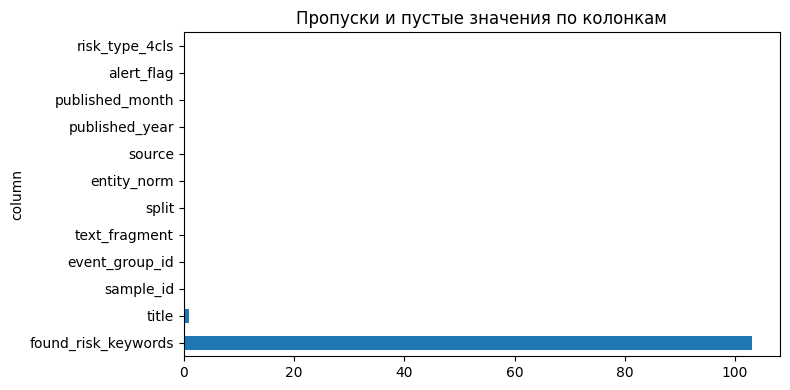

In [5]:
# Пустые значения в текстовых и служебных колонках могут ломать vectorizer или искажать EDA.
missing_sorted = missing.sort_values('missing_or_empty', ascending=False)
display(missing_sorted)
missing_sorted.set_index('column')['missing_or_empty'].plot(kind='barh', figsize=(8, 4), title='Пропуски и пустые значения по колонкам')
plt.tight_layout(); plt.show()

### Вывод

Основные обязательные поля присутствуют. Пустые значения встречаются ограниченно и не выглядят критичными для обучения, если перед моделированием заполнить текстовые поля пустой строкой.

ML-интерпретация: TF-IDF не принимает `NaN`, поэтому перед обучением нужно явно конкатенировать текстовые поля через `fillna('')`.

Риск: пустой `title` или `found_risk_keywords` не является ошибкой разметки, но пустой `text_fragment` был бы критичным.

Решение: в pipeline модели использовать безопасную сборку текста: `title.fillna('') + ' ' + text_fragment.fillna('') + ' Банк: ' + entity_norm.fillna('')`.

## 5. Дубликаты

In [6]:
# Проверяем ID-дубли и точные текстовые дубли: они могут завышать качество модели,
# если одинаковый текст окажется и в train, и в valid/test.
duplicate_checks = pd.DataFrame([
    {'check': 'duplicate sample_id', 'count': int(df['sample_id'].duplicated().sum())},
    {'check': 'duplicate text_fragment', 'count': int(df['text_fragment'].duplicated().sum())},
    {'check': 'duplicate title + text_fragment + entity_norm', 'count': int(df.duplicated(['title', 'text_fragment', 'entity_norm']).sum())},
])
display(duplicate_checks)

text_dupes = df[df['text_fragment'].duplicated(keep=False)].sort_values('text_fragment')
display(text_dupes[['sample_id', 'split', 'event_group_id', 'entity_norm', 'title', 'text_fragment']].head(10))

,check,count
0,duplicate sample_id,0
1,duplicate text_fragment,61
2,duplicate title + text_fragment + entity_norm,0


,sample_id,split,event_group_id,entity_norm,title,text_fragment
401,ml_000402,train,eg_000374,Сбербанк,"""Роснефть"" считает решение Европейского суда незаконным и политизированным","""Роснефть"" считает решение Европейского суда незаконным и политизированным nСовет ЕС ввел экономические санкции в отношении России в июле 2014 года, включая..."
403,ml_000404,train,eg_000374,ВТБ,"""Роснефть"" считает решение Европейского суда незаконным и политизированным","""Роснефть"" считает решение Европейского суда незаконным и политизированным nСовет ЕС ввел экономические санкции в отношении России в июле 2014 года, включая..."
104,ml_000105,train,eg_000098,Сбербанк,«Что за контора „Конкорд“? — Кейтерингом занимаются»,"«Что за контора „Конкорд“? — Кейтерингом занимаются» По версии следствия (расследование вел следственный департамент МВД РФ), участники хакерской группы Lur..."
757,ml_000758,train,eg_000098,ВТБ,«Что за контора „Конкорд“? — Кейтерингом занимаются»,"«Что за контора „Конкорд“? — Кейтерингом занимаются» По версии следствия (расследование вел следственный департамент МВД РФ), участники хакерской группы Lur..."
289,ml_000290,train,eg_000248,Райффайзенбанк,Банк России в июле может начать тестировать платежи по QR-коду,Банк России в июле может начать тестировать платежи по QR-коду Систему для всех клиентов 11 банков - участников системы начали внедрять в конце февраля. В н...
262,ml_000263,train,eg_000248,Совкомбанк,Банк России в июле может начать тестировать платежи по QR-коду,Банк России в июле может начать тестировать платежи по QR-коду Систему для всех клиентов 11 банков - участников системы начали внедрять в конце февраля. В н...
285,ml_000286,valid,eg_000270,ВТБ,Банкиры-нелегалы обналичили в Петербурге миллиарды рублей,"Банкиры-нелегалы обналичили в Петербурге миллиарды рублей Были установлены четверо ее членов, десять фирм-однодневок, которые использовались в схеме, а такж..."
701,ml_000702,valid,eg_000270,Сбербанк,Банкиры-нелегалы обналичили в Петербурге миллиарды рублей,"Банкиры-нелегалы обналичили в Петербурге миллиарды рублей Были установлены четверо ее членов, десять фирм-однодневок, которые использовались в схеме, а такж..."
550,ml_000551,train,eg_000355,Альфа-Банк,Банковские вклады будут массово блокироваться – Инициатива министра МВД ставит под угрозу «бедные» накопления россиян,"Банковские вклады будут массово блокироваться – Инициатива министра МВД ставит под угрозу «бедные» накопления россиян Это и сейчас происходит в случае, если..."
380,ml_000381,train,eg_000355,Т-Банк,Банковские вклады будут массово блокироваться – Инициатива министра МВД ставит под угрозу «бедные» накопления россиян,"Банковские вклады будут массово блокироваться – Инициатива министра МВД ставит под угрозу «бедные» накопления россиян Это и сейчас происходит в случае, если..."


### Вывод

`sample_id` не дублируется, а точных дублей по полному ключу `title + text_fragment + entity_norm` нет. При этом одинаковые или почти одинаковые новости могут встречаться для разных банков: это не дубликат строки, а несколько наблюдений одного инфоповода с разными `entity_norm`. Такие строки должны контролироваться через `event_group_id`.

ML-интерпретация: отсутствие дублей по полному ключу снижает риск запоминания полностью одинаковой строки, но повтор одного инфоповода для разных банков всё равно важен для валидации. Если такие строки попадут в разные split, метрики могут быть завышены.

Риск: exact duplicate проверка не покрывает случаи, когда один инфоповод повторяется для разных банков или пересказывается разными словами.

Решение: использовать `event_group_id` и near-duplicate проверку через TF-IDF similarity; строки одной группы должны попадать только в один split.

## 6. Распределение target `alert_flag`

,alert_flag,count,share
0,0,585,0.697259
1,1,254,0.302741


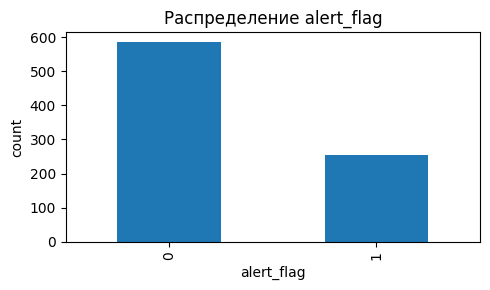

Positive share: 0.303


In [7]:
# Проверяем дисбаланс target: от него зависит выбор метрик и class_weight.
alert_counts = df['alert_flag'].value_counts().sort_index().rename_axis('alert_flag').reset_index(name='count')
alert_counts['share'] = alert_counts['count'] / len(df)
display(alert_counts)
alert_counts.set_index('alert_flag')['count'].plot(kind='bar', figsize=(5, 3), title='Распределение alert_flag')
plt.ylabel('count')
plt.tight_layout(); plt.show()
positive_share = alert_counts.loc[alert_counts['alert_flag'].astype(str) == '1', 'share'].sum()
print(f'Positive share: {positive_share:.3f}')

### Вывод

Положительный класс `alert_flag = 1` встречается реже отрицательного: примерно 30% против 70%. Это управляемый, но заметный дисбаланс.

ML-интерпретация: accuracy может быть завышенной, если модель часто предсказывает класс 0. Для оценки нужны precision, recall, F1 и PR-AUC.

Риск: модель может пропускать реальные риск-сигналы, особенно если оптимизировать только accuracy.

Решение: использовать `class_weight='balanced'`, контролировать recall/F1 по positive-классу и не балансировать valid/test искусственно.

## 7. Распределение `risk_type_4cls`

,risk_type_4cls,count,share
0,no_risk,585,0.697259
1,cyber_risk,111,0.132300
2,operational_risk,97,0.115614
3,regulatory_risk,46,0.054827


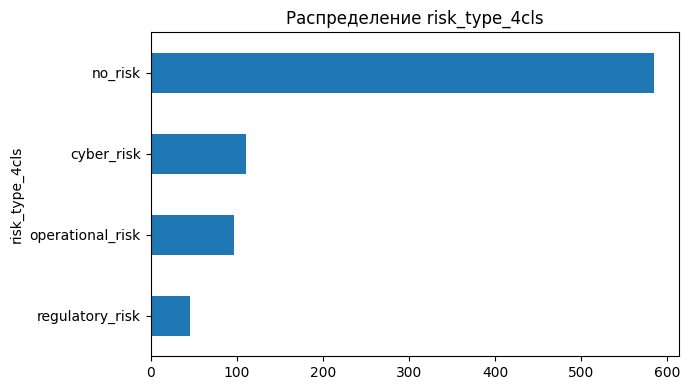

alert_flag,0,1
risk_type_4cls,,
cyber_risk,0,111
no_risk,585,0
operational_risk,0,97
regulatory_risk,0,46


split,test,train,valid
risk_type_4cls,,,
cyber_risk,16,81,14
no_risk,88,409,88
operational_risk,17,69,11
regulatory_risk,5,28,13


,sample_id,risk_type_4cls,alert_flag,title


,sample_id,risk_type_4cls,alert_flag,title


In [8]:
# Проверяем структуру 4-классовой разметки и её согласованность с бинарным target.
risk_counts = df['risk_type_4cls'].value_counts().rename_axis('risk_type_4cls').reset_index(name='count')
risk_counts['share'] = risk_counts['count'] / len(df)
display(risk_counts)
risk_counts.set_index('risk_type_4cls')['count'].sort_values().plot(kind='barh', figsize=(7, 4), title='Распределение risk_type_4cls')
plt.tight_layout(); plt.show()

display(pd.crosstab(df['risk_type_4cls'], df['alert_flag']))
display(pd.crosstab(df['risk_type_4cls'], df['split']))

incons_no_risk = df[(df['risk_type_4cls'] == 'no_risk') & (df['alert_flag'].astype(str) == '1')]
incons_risk = df[(df['risk_type_4cls'] != 'no_risk') & (df['alert_flag'].astype(str) == '0')]
display(incons_no_risk[['sample_id', 'risk_type_4cls', 'alert_flag', 'title']].head())
display(incons_risk[['sample_id', 'risk_type_4cls', 'alert_flag', 'title']].head())

### Вывод

`no_risk` доминирует и соответствует отрицательному классу. Риск-классы (`cyber_risk`, `operational_risk`, `regulatory_risk`) соответствуют положительным примерам.

ML-интерпретация: `risk_type_4cls` полезен для анализа структуры ошибок и будущей multi-class задачи, но для бинарной модели его нельзя использовать как feature, потому что это связанная с target разметка.

Риск: классы риска меньше, чем `no_risk`; multi-class метрики будут менее стабильны, особенно по `regulatory_risk`.

Решение: основной задачей считать бинарную классификацию `alert_flag`, а multi-class использовать как дополнительный эксперимент и анализ ошибок.

## 8. Текстовый EDA

,title_len,text_len,text_words,risk_keyword_count
count,839.000000,839.000000,839.000000,839.000000
mean,61.971395,438.030989,58.724672,1.038141
std,18.775756,183.466635,23.484149,0.551392
min,0.000000,63.000000,9.000000,0.000000
25%,50.500000,319.000000,43.000000,1.000000
50%,61.000000,414.000000,56.000000,1.000000
75%,73.000000,542.500000,72.000000,1.000000
max,167.000000,1387.000000,171.000000,4.000000


title_len           text_len        text_words         \
                 mean median        mean median       mean median   
alert_flag                                                          
0           61.235897   60.0  452.309402  429.0  60.517949   58.0   
1           63.665354   62.0  405.145669  377.0  54.594488   51.5   

           risk_keyword_count         
                         mean median  
alert_flag                            
0                    0.984615    1.0  
1                    1.161417    1.0

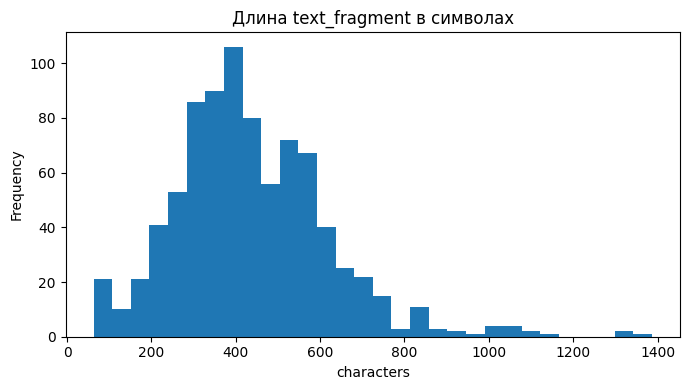

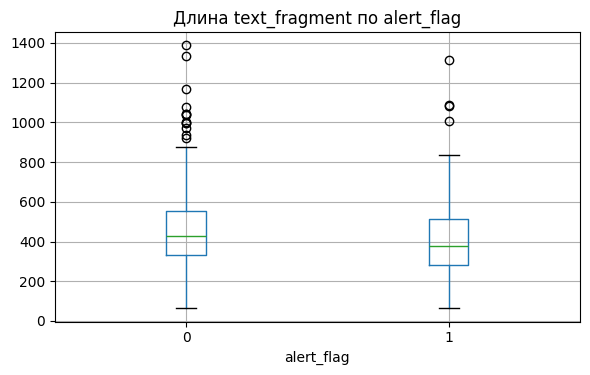

,keyword,count
0,сбой,112
1,санкции,108
2,мошенничество,80
3,суд,67
4,мошенники,61
5,иск,56
6,не работает,38
7,хищение,36
8,злоумышленники,35
9,ограничения,32


In [9]:
# Анализируем длины текстов: слишком короткие фрагменты ухудшают качество TF-IDF,
# а сильные различия длины между классами могут стать простым shortcut для модели.
eda_df = df.copy()
eda_df['title_len'] = eda_df['title'].astype(str).str.len()
eda_df['text_len'] = eda_df['text_fragment'].astype(str).str.len()
eda_df['text_words'] = eda_df['text_fragment'].astype(str).str.split().map(len)
eda_df['risk_keyword_count'] = eda_df['found_risk_keywords'].astype(str).map(lambda x: 0 if x.strip() == '' else len([p for p in x.split(';') if p.strip()]))

display(eda_df[['title_len', 'text_len', 'text_words', 'risk_keyword_count']].describe())
display(eda_df.groupby('alert_flag')[['title_len', 'text_len', 'text_words', 'risk_keyword_count']].agg(['mean', 'median']))

eda_df['text_len'].plot(kind='hist', bins=30, figsize=(7, 4), title='Длина text_fragment в символах')
plt.xlabel('characters')
plt.tight_layout(); plt.show()

eda_df.boxplot(column='text_len', by='alert_flag', figsize=(6, 4))
plt.title('Длина text_fragment по alert_flag')
plt.suptitle('')
plt.tight_layout(); plt.show()

keywords = []
for value in df['found_risk_keywords'].astype(str):
    keywords.extend([part.strip() for part in value.split(';') if part.strip()])
keyword_counts = pd.Series(keywords).value_counts().rename_axis('keyword').reset_index(name='count')
display(keyword_counts.head(20))

### Вывод

Фрагменты имеют достаточную длину для TF-IDF baseline: медианная длина около нескольких сотен символов, пустых текстов нет. Риск-ключевые слова встречаются не во всех строках и не должны быть единственным основанием классификации.

ML-интерпретация: модель сможет использовать лексические признаки из `title` и `text_fragment`. При этом длина текста и ключевые слова могут стать shortcut-признаками.

Риск: если использовать `found_risk_keywords` как feature, модель может воспроизвести rule-based предразметку вместо понимания контекста банка.

Решение: для первой честной модели использовать `title + text_fragment + entity_norm`; `found_risk_keywords` оставить для EDA и error analysis.

## 9. Анализ источников

,source,count
0,buriy,267
1,lenta,196
2,ods_tass,186
3,telegram_contest,108
4,taiga_fontanka,82


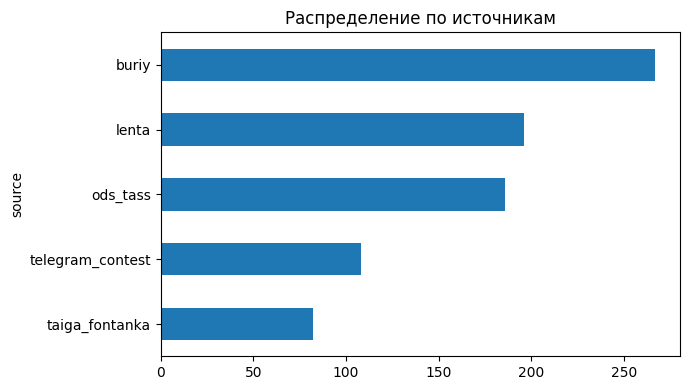

alert_flag,0,1
source,,
buriy,0.723,0.277
lenta,0.755,0.245
ods_tass,0.710,0.290
taiga_fontanka,0.537,0.463
telegram_contest,0.630,0.370


risk_type_4cls,cyber_risk,no_risk,operational_risk,regulatory_risk
source,,,,
buriy,28,193,28,18
lenta,13,148,22,13
ods_tass,27,132,18,9
taiga_fontanka,20,44,14,4
telegram_contest,23,68,15,2


In [10]:
# Проверяем source bias: если источник сильно связан с target, модель может учить стиль источника,
# а не содержательные риск-сигналы.
source_counts = df['source'].value_counts().rename_axis('source').reset_index(name='count')
display(source_counts)
source_counts.set_index('source')['count'].sort_values().plot(kind='barh', figsize=(7, 4), title='Распределение по источникам')
plt.tight_layout(); plt.show()

display(pd.crosstab(df['source'], df['alert_flag'], normalize='index').round(3))
display(pd.crosstab(df['source'], df['risk_type_4cls']))

### Вывод

Данные представлены пятью источниками, причём часть источников заметно крупнее остальных. Распределение классов по источникам может отличаться.

ML-интерпретация: `source` может быть полезен, но несёт риск переобучения на стиль конкретного источника.

Риск: модель может хуже работать на новых источниках медиамониторинга.

Решение: для базовой модели можно сначала не использовать `source`, а затем сравнить качество с ним и без него. В отчёте обязательно указать ограничение по источникам.

## 10. Анализ годов и месяцев

,published_year,count
0,2002,1
1,2003,1
2,2006,2
3,2007,6
4,2008,17
5,2009,25
6,2010,13
7,2011,15
8,2012,31
9,2013,41


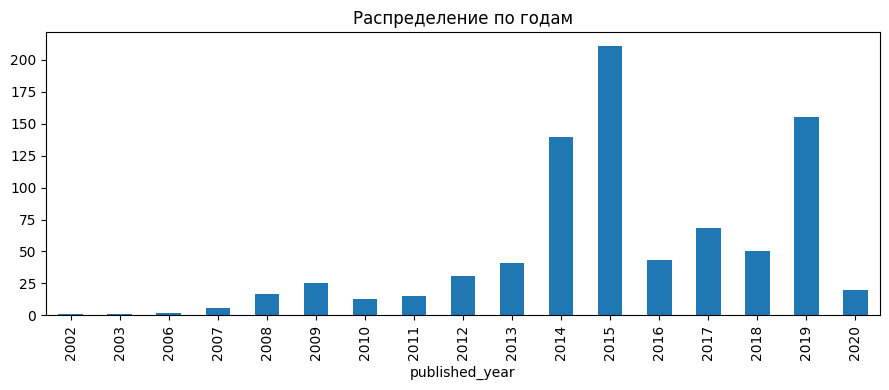

alert_flag,0,1
published_year,,
2002,1,0
2003,1,0
2006,1,1
2007,5,1
2008,14,3
2009,18,7
2010,9,4
2011,10,5
2012,19,12


alert_flag,0,1
published_month,,
1,27,6
2,34,5
3,28,21
4,56,22
5,55,13
6,38,25
7,40,17
8,31,26
9,65,29


In [11]:
# Проверяем временной сдвиг: старые новости могут отличаться от современных по лексике и типам рисков.
year_counts = df['published_year'].value_counts().sort_index().rename_axis('published_year').reset_index(name='count')
display(year_counts)
year_counts.set_index('published_year')['count'].plot(kind='bar', figsize=(9, 4), title='Распределение по годам')
plt.tight_layout(); plt.show()

display(pd.crosstab(df['published_year'], df['alert_flag']))
display(pd.crosstab(df['published_month'], df['alert_flag']))

### Вывод

Датасет покрывает 2002-2020 годы, при этом есть концентрация в отдельных годах. Это типично для исторического новостного корпуса.

ML-интерпретация: язык банковских рисков и набор актуальных событий меняется со временем. Модель, обученная на старых новостях, может хуже переноситься на свежие данные.

Риск: temporal drift — деградация качества на новых периодах.

Решение: для учебной задачи использовать group-aware split, но в продуктовой версии дополнительно проверять time-based validation или отдельный свежий holdout.

## 11. Качество разметки

In [15]:
# Проверяем базовые логические правила разметки.
no_risk_alert_1 = df[(df['risk_type_4cls'] == 'no_risk') & (df['alert_flag'].astype(str) == '1')]
risk_alert_0 = df[(df['risk_type_4cls'] != 'no_risk') & (df['alert_flag'].astype(str) == '0')]
pos_without_keywords = df[(df['alert_flag'].astype(str) == '1') & (df['found_risk_keywords'].astype(str).str.strip() == '')]
neg_with_keywords = df[(df['alert_flag'].astype(str) == '0') & (df['found_risk_keywords'].astype(str).str.strip() != '')]

quality_checks = pd.DataFrame([
    {'check': 'Ошибка: no_risk, но alert_flag=1', 'what_it_means': 'Положительный alert без класса риска', 'rows': len(no_risk_alert_1)},
    {'check': 'Ошибка: риск-класс, но alert_flag=0', 'what_it_means': 'Есть класс риска, но карточка отключена', 'rows': len(risk_alert_0)},
    {'check': 'Проверка: positive без risk keywords', 'what_it_means': 'Не ошибка автоматически: риск может быть выражен без словаря', 'rows': len(pos_without_keywords)},
    {'check': 'Проверка: negative с risk keywords', 'what_it_means': 'Не ошибка автоматически: риск-слово может относиться не к банку', 'rows': len(neg_with_keywords)},
])
display(quality_checks)

# Пустая таблица здесь означает, что нарушений данного типа не найдено.
def show_examples(frame, columns, title, n=5):
    print(title)
    if frame.empty:
        print('Нарушений не найдено.\n')
    else:
        display(frame[columns].head(n))

show_examples(
    no_risk_alert_1,
    ['sample_id', 'title', 'text_fragment'],
    '1. Ошибка: no_risk, но alert_flag=1'
)
show_examples(
    risk_alert_0,
    ['sample_id', 'risk_type_4cls', 'title', 'text_fragment'],
    '2. Ошибка: риск-класс, но alert_flag=0'
)
show_examples(
    pos_without_keywords,
    ['sample_id', 'risk_type_4cls', 'title'],
    '3. Проверка: positive без risk keywords'
)
show_examples(
    neg_with_keywords,
    ['sample_id', 'alert_flag', 'found_risk_keywords', 'title'],
    '4. Примеры negative-строк, где есть риск-слова, но alert_flag=0'
)

,check,what_it_means,rows
0,"Ошибка: no_risk, но alert_flag=1",Положительный alert без класса риска,0
1,"Ошибка: риск-класс, но alert_flag=0","Есть класс риска, но карточка отключена",0
2,Проверка: positive без risk keywords,Не ошибка автоматически: риск может быть выражен без словаря,0
3,Проверка: negative с risk keywords,Не ошибка автоматически: риск-слово может относиться не к банку,482


1. Ошибка: no_risk, но alert_flag=1
Нарушений не найдено.

2. Ошибка: риск-класс, но alert_flag=0
Нарушений не найдено.

3. Проверка: positive без risk keywords
Нарушений не найдено.

4. Примеры negative-строк, где есть риск-слова, но alert_flag=0


,sample_id,alert_flag,found_risk_keywords,title
2,ml_000003,0,санкции,"Exxon и ""Роснефть"" прекратили бурение в Арктике из-за санкций"
4,ml_000005,0,клиентская база,«Открытие» и «Росгосстрах» создадут крупнейшую частную финансовую группу
5,ml_000006,0,кибератака,Центробанк требует защитить информацию от хакеров
6,ml_000007,0,суд,Суд признал банкротом группу JFC Владимира Кехмана
7,ml_000008,0,регулятор,"Финансовый регулятор приостановил выдачу инвестпаев ""ОФГ ИНВЕСТ"""


### Вывод

Этот блок проверяет не модель, а согласованность разметки. Первые две строки таблицы — настоящие логические ошибки: `no_risk` не должен иметь `alert_flag = 1`, а риск-класс не должен иметь `alert_flag = 0`. В датасете таких ошибок нет.

Строка `negative с risk keywords = 482` не означает 482 ошибки. Это означает, что в отрицательных примерах часто встречаются риск-слова вроде `санкции`, `суд`, `регулятор`, `кибератака`, но итоговая метка остаётся `alert_flag = 0`. В нижней таблице поэтому явно показан `alert_flag`: все эти примеры отрицательные, хотя словарь риск-слов что-то нашёл.

Почему так бывает: риск-слово может относиться не к банку из `entity_norm`, а к другой организации, стране, судебному делу или общему контексту. Банк может быть просто упомянут, быть кредитором, платёжным посредником или комментатором. Значит, наличие риск-слова — это сигнал для проверки, но не достаточное условие для positive-класса.

ML-интерпретация: модель не должна учить простое правило “есть риск-слово => alert_flag = 1”. Ей нужно учитывать контекст банка и текст вокруг события.

Риск: если использовать `found_risk_keywords` как feature, модель может переобучиться на шумные слова и давать много ложных алертов.

Решение: для baseline использовать `title + text_fragment + entity_norm`, а `found_risk_keywords` оставить для анализа ошибок и контроля качества разметки.

## 12. Train/valid/test split

In [16]:
# Проверяем split: valid/test должны быть похожи на train по target,
# а event_group_id не должен пересекаться между split.
split_counts = df['split'].value_counts().rename_axis('split').reset_index(name='count')
display(split_counts)
display(pd.crosstab(df['split'], df['alert_flag']))
display(pd.crosstab(df['split'], df['risk_type_4cls']))
display(pd.crosstab(df['split'], df['source']))
display(pd.crosstab(df['split'], df['published_year']))

event_group_leakage = df.groupby('event_group_id')['split'].nunique().gt(1).sum()
sample_id_dupes = df['sample_id'].duplicated().sum()
print('event_group_id leakage:', int(event_group_leakage))
print('sample_id duplicates:', int(sample_id_dupes))

,split,count
0,train,587
1,test,126
2,valid,126


alert_flag,0,1
split,,
test,88,38
train,409,178
valid,88,38


risk_type_4cls,cyber_risk,no_risk,operational_risk,regulatory_risk
split,,,,
test,16,88,17,5
train,81,409,69,28
valid,14,88,11,13


source,buriy,lenta,ods_tass,taiga_fontanka,telegram_contest
split,,,,,
test,37,31,25,17,16
train,187,137,128,58,77
valid,43,28,33,7,15


published_year,2002,2003,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
split,,,,,,,,,,,,,,,,,
test,0,0,0,0,3,5,5,3,6,5,18,26,10,13,6,22,4
train,0,0,1,5,10,17,8,10,19,33,94,156,29,48,34,109,14
valid,1,1,1,1,4,3,0,2,6,3,28,29,4,7,10,24,2


event_group_id leakage: 0
sample_id duplicates: 0


### Вывод

Split имеет пропорции около 70/15/15. `event_group_id` не пересекается между split, то есть строки одного сгруппированного инфоповода не попадают одновременно в обучение и проверку.

ML-интерпретация: group-aware split даёт более честную оценку качества, чем случайное разбиение по строкам.

Риск: даже при group split могут оставаться семантически похожие новости, если алгоритм группировки их не объединил.

Решение: дополнительно проверять exact duplicates и near-duplicates между split.

## 13. Exact duplicates между split

In [18]:
# Проверяем точные текстовые совпадения между split: это прямой leakage для TF-IDF модели.
def cross_split_duplicate_report(data, key_cols):
    grouped = data.groupby(key_cols, dropna=False)['split'].nunique().reset_index(name='n_splits')
    leaking_keys = grouped[grouped['n_splits'] > 1]
    if leaking_keys.empty:
        return leaking_keys, data.head(0)
    rows = data.merge(leaking_keys[key_cols], on=key_cols, how='inner').sort_values(key_cols + ['split'])
    return leaking_keys, rows

text_keys, text_leaks = cross_split_duplicate_report(df, ['text_fragment'])
combo_keys, combo_leaks = cross_split_duplicate_report(df, ['title', 'text_fragment', 'entity_norm'])

display(pd.DataFrame([
    {'check': 'text_fragment exact duplicate across split', 'leaking_keys': len(text_keys), 'rows': len(text_leaks)},
    {'check': 'title + text_fragment + entity_norm duplicate across split', 'leaking_keys': len(combo_keys), 'rows': len(combo_leaks)},
]))
display(text_leaks[['sample_id', 'split', 'event_group_id', 'entity_norm', 'title']].head(10))

,check,leaking_keys,rows
0,text_fragment exact duplicate across split,0,0
1,title + text_fragment + entity_norm duplicate across split,0,0


,sample_id,split,event_group_id,entity_norm,title


### Вывод

Проверка показывает, есть ли точные текстовые повторы между train/valid/test. Такие повторы особенно опасны для TF-IDF, потому что модель может почти дословно запомнить пример.

ML-интерпретация: если exact duplicates между split отсутствуют, оценка модели менее подвержена прямому запоминанию.

Риск: точных дублей может не быть, но остаются близкие пересказы одного инфоповода.

Решение: использовать near-duplicate анализ на следующем шаге.

## 14. Near-duplicates между split

In [19]:
# Ищем похожие тексты между разными split. Проверяем word n-grams и char n-grams:
# char n-grams помогают находить близкие формулировки даже при небольших изменениях слов.
compare_text = (df['title'].astype(str) + ' ' + df['text_fragment'].astype(str)).str.lower().str.replace('ё', 'е')

def find_cross_split_pairs(texts, vectorizer, threshold=0.80):
    matrix = vectorizer.fit_transform(texts)
    sim = (matrix @ matrix.T).tocoo()
    pairs = []
    split_values = df['split'].to_dict()
    for i, j, value in zip(sim.row, sim.col, sim.data):
        if i >= j or value < threshold:
            continue
        # Нас интересуют только пары, которые оказались в разных split.
        # Именно они могут быть candidates на leakage.
        if split_values[i] == split_values[j]:
            continue
        pairs.append({
            'sample_id_1': df.at[i, 'sample_id'],
            'split_1': df.at[i, 'split'],
            'event_group_id_1': df.at[i, 'event_group_id'],
            'title_1': df.at[i, 'title'],
            'sample_id_2': df.at[j, 'sample_id'],
            'split_2': df.at[j, 'split'],
            'event_group_id_2': df.at[j, 'event_group_id'],
            'title_2': df.at[j, 'title'],
            'similarity': round(float(value), 4),
            'alert_flag_1': df.at[i, 'alert_flag'],
            'alert_flag_2': df.at[j, 'alert_flag'],
            'risk_type_1': df.at[i, 'risk_type_4cls'],
            'risk_type_2': df.at[j, 'risk_type_4cls'],
        })
    return pd.DataFrame(pairs).sort_values('similarity', ascending=False) if pairs else pd.DataFrame()

word_pairs_080 = find_cross_split_pairs(compare_text, TfidfVectorizer(ngram_range=(1, 2), min_df=2), threshold=0.80)
word_pairs_085 = find_cross_split_pairs(compare_text, TfidfVectorizer(ngram_range=(1, 2), min_df=2), threshold=0.85)
char_pairs_080 = find_cross_split_pairs(compare_text, TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2), threshold=0.80)
char_pairs_085 = find_cross_split_pairs(compare_text, TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=2), threshold=0.85)

summary_near = pd.DataFrame([
    {'method': 'word n-grams 1-2', 'threshold': 0.80, 'cross_split_pairs_found': len(word_pairs_080)},
    {'method': 'word n-grams 1-2', 'threshold': 0.85, 'cross_split_pairs_found': len(word_pairs_085)},
    {'method': 'char n-grams 3-5', 'threshold': 0.80, 'cross_split_pairs_found': len(char_pairs_080)},
    {'method': 'char n-grams 3-5', 'threshold': 0.85, 'cross_split_pairs_found': len(char_pairs_085)},
])
display(summary_near)

print('Примеры word-level near-duplicates между разными split:')
display(word_pairs_080.head(10))

print('Примеры char-level near-duplicates между разными split:')
display(char_pairs_080.head(10))

,method,threshold,cross_split_pairs_found
0,word n-grams 1-2,0.80,0
1,word n-grams 1-2,0.85,0
2,char n-grams 3-5,0.80,7
3,char n-grams 3-5,0.85,3


Примеры word-level near-duplicates между разными split:


""


Примеры char-level near-duplicates между разными split:


,sample_id_1,split_1,event_group_id_1,title_1,sample_id_2,split_2,event_group_id_2,title_2,similarity,alert_flag_1,alert_flag_2,risk_type_1,risk_type_2
6,ml_000336,train,eg_000315,ЦБ вскоре объявит тарифы на платежи по QR-коду в Системе быстрых платежей,ml_000398,valid,eg_000371,ЦБ заявил о нулевой доле хищений в системе быстрых платежей,0.8525,0,0,no_risk,no_risk
5,ml_000336,train,eg_000315,ЦБ вскоре объявит тарифы на платежи по QR-коду в Системе быстрых платежей,ml_000562,valid,eg_000371,ЦБ заявил о нулевой доле хищений в системе быстрых платежей,0.8525,0,0,no_risk,no_risk
4,ml_000336,train,eg_000315,ЦБ вскоре объявит тарифы на платежи по QR-коду в Системе быстрых платежей,ml_000659,valid,eg_000371,ЦБ заявил о нулевой доле хищений в системе быстрых платежей,0.8525,0,0,no_risk,no_risk
2,ml_000214,test,eg_000040,Крупные банки за месяц потеряли почти 10% вкладов,ml_000598,train,eg_000320,Крупные банки России потеряли десятую часть вкладов за месяц,0.8279,0,0,no_risk,no_risk
1,ml_000042,test,eg_000040,Крупные банки за месяц потеряли почти 10% вкладов,ml_000342,train,eg_000320,Крупные банки России потеряли десятую часть вкладов за месяц,0.8279,0,0,no_risk,no_risk
0,ml_000042,test,eg_000040,Крупные банки за месяц потеряли почти 10% вкладов,ml_000598,train,eg_000320,Крупные банки России потеряли десятую часть вкладов за месяц,0.8279,0,0,no_risk,no_risk
3,ml_000214,test,eg_000040,Крупные банки за месяц потеряли почти 10% вкладов,ml_000342,train,eg_000320,Крупные банки России потеряли десятую часть вкладов за месяц,0.8279,0,0,no_risk,no_risk


### Вывод по результатам near-duplicate анализа

Анализ проводился методом попарного сравнения текстов на основе TF-IDF cosine similarity. Проверялись пары строк, которые находятся в разных split.

В результате были найдены пары с высоким лексическим сходством между разными split. При ручной проверке видно, что часть таких совпадений является артефактом TF-IDF: метод фиксирует общие термины банковской тематики (`ЦБ`, `платежи`, `вклады`, `система быстрых платежей`), хотя сами новости могут относиться к разным инфоповодам.

Отдельно зафиксирован один содержательно близкий случай: пары новостей про то, что крупные банки потеряли часть вкладов. Эти строки находятся в разных `event_group_id` и разных split, поэтому формально не нарушают правило group split. Противоречий в разметке нет: строки имеют `alert_flag = 0` и `risk_type_4cls = no_risk`.

ML-интерпретация: критической утечки риск-событий между split не выявлено. Проверка `event_group_id` показывает отсутствие пересечения групп между train/valid/test. Найденные near-duplicate пары относятся к `no_risk` и не создают противоречий в разметке, но могут незначительно завышать метрики TF-IDF-моделей.

Риск: TF-IDF ориентируется на лексическое совпадение, поэтому может находить похожими разные новости с общей банковской терминологией. При этом отдельные содержательно близкие `no_risk` пары всё же могут встречаться между split.

Решение: использовать текущий `event_group_id` split как основной вариант валидации и оставить near-duplicate анализ как контроль качества split. Результаты valid/test следует интерпретировать с учётом этого ограничения. Для более строгой проверки можно использовать более высокий порог TF-IDF similarity или семантические эмбеддинги, например sentence-transformers.

## 15. Leakage-анализ признаков

In [20]:
# Оцениваем признаки с точки зрения leakage: не все колонки датасета являются допустимыми feature.
feature_leakage = pd.DataFrame([
    {'feature': 'sample_id', 'use_in_model': 'нет', 'leakage_risk': 'высокий', 'reason': 'технический ID', 'decision': 'исключить'},
    {'feature': 'event_group_id', 'use_in_model': 'нет', 'leakage_risk': 'высокий', 'reason': 'группа для split', 'decision': 'использовать только для валидации'},
    {'feature': 'split', 'use_in_model': 'нет', 'leakage_risk': 'высокий', 'reason': 'служебная колонка', 'decision': 'исключить'},
    {'feature': 'alert_flag', 'use_in_model': 'target', 'leakage_risk': 'максимальный', 'reason': 'целевая переменная', 'decision': 'только target'},
    {'feature': 'risk_type_4cls', 'use_in_model': 'нет для binary', 'leakage_risk': 'высокий', 'reason': 'связанная разметка', 'decision': 'только analysis/multiclass target'},
    {'feature': 'found_risk_keywords', 'use_in_model': 'осторожно', 'leakage_risk': 'средний/высокий', 'reason': 'может отражать rule-based предразметку', 'decision': 'не использовать в первом baseline'},
    {'feature': 'title', 'use_in_model': 'да', 'leakage_risk': 'низкий', 'reason': 'текст новости', 'decision': 'использовать'},
    {'feature': 'text_fragment', 'use_in_model': 'да', 'leakage_risk': 'низкий', 'reason': 'основной текстовый сигнал', 'decision': 'использовать'},
    {'feature': 'entity_norm', 'use_in_model': 'да', 'leakage_risk': 'средний', 'reason': 'может переобучать на конкретные банки', 'decision': 'использовать и контролировать ошибки'},
    {'feature': 'source', 'use_in_model': 'осторожно', 'leakage_risk': 'средний', 'reason': 'source bias', 'decision': 'сравнить модели с/без source'},
    {'feature': 'published_year/month', 'use_in_model': 'осторожно', 'leakage_risk': 'средний', 'reason': 'temporal drift', 'decision': 'использовать только после проверки'},
])
display(feature_leakage)

,feature,use_in_model,leakage_risk,reason,decision
0,sample_id,нет,высокий,технический ID,исключить
1,event_group_id,нет,высокий,группа для split,использовать только для валидации
2,split,нет,высокий,служебная колонка,исключить
3,alert_flag,target,максимальный,целевая переменная,только target
4,risk_type_4cls,нет для binary,высокий,связанная разметка,только analysis/multiclass target
5,found_risk_keywords,осторожно,средний/высокий,может отражать rule-based предразметку,не использовать в первом baseline
6,title,да,низкий,текст новости,использовать
7,text_fragment,да,низкий,основной текстовый сигнал,использовать
8,entity_norm,да,средний,может переобучать на конкретные банки,использовать и контролировать ошибки
9,source,осторожно,средний,source bias,сравнить модели с/без source


### Вывод

Не все колонки пригодны как признаки. Честный baseline должен использовать прежде всего `title`, `text_fragment`, `entity_norm`.

ML-интерпретация: исключение leakage-признаков делает оценку качества более реалистичной и снижает риск переоценки модели.

Риск: `found_risk_keywords` и `risk_type_4cls` могут сделать задачу искусственно лёгкой, потому что они связаны с логикой разметки.

Решение: для первой модели не использовать `risk_type_4cls`, `found_risk_keywords`, `split`, `sample_id`, `event_group_id`; оставить их для EDA и контроля качества.

## 16. Финальный алгоритм формирования выборки

1. Исходный поток новостей RuNews.
2. Поиск банковских упоминаний.
3. Выделение фрагмента вокруг банка.
4. Фильтрация нерелевантных или слишком коротких фрагментов.
5. Разметка `alert_flag` и `risk_type_4cls`.
6. Формирование `event_group_id` для группировки одного инфоповода.
7. Удаление точных дублей.
8. Проверка near-duplicates.
9. Group-aware split на train/valid/test.
10. Финальная проверка качества split.

### Вывод

Алгоритм формирует не просто набор строк, а датасет с контролем утечки между train/valid/test.

ML-интерпретация: такая схема ближе к реальному сценарию, где модель должна обобщать на новые инфоповоды, а не узнавать похожий текст из train.

Риск: группировка near-duplicates не идеальна и может пропустить часть семантически близких новостей.

Решение: в следующей версии улучшить `event_group_id` до более строгого `event_cluster_id` с threshold >= 0.80 и ручной проверкой спорных пар.

## 17. Финальная стратегия валидации

Рекомендуемая стратегия:

- использовать train/valid/test примерно 70/15/15;
- split должен быть group-aware по `event_group_id`;
- valid и test не балансировать искусственно;
- если нужен balanced train, создавать его только из train;
- метрики: Precision, Recall, F1, PR-AUC, confusion matrix;
- для продуктового сценария дополнительно смотреть Precision@K.

### Вывод

Датасет пригоден для обучения учебного бинарного baseline `alert_flag`, если использовать group-aware split и не подавать leakage-признаки в модель.

ML-интерпретация: основные выводы valid/test будут полезны для сравнения простых моделей, но не являются промышленной гарантией качества.

Риск: размер датасета и исторический период RuNews ограничивают переносимость результатов на свежий медиамониторинг.

Решение: начать с TF-IDF + Logistic Regression / LinearSVC, затем анализировать ошибки и расширять датасет по редким риск-сценариям.

## 18. Дополнительная multi-class задача

Помимо основной бинарной задачи `alert_flag`, датасет можно использовать для дополнительной многоклассовой классификации:

`title + text_fragment + entity_norm -> risk_type_4cls`

Классы:

* `no_risk`
* `cyber_risk`
* `operational_risk`
* `regulatory_risk`

### Вывод

Многоклассовая постановка является логичным расширением основной задачи. Если бинарная модель отвечает на вопрос «есть ли риск-сигнал?», то multi-class модель уточняет тип риска.

В текущей работе multi-class классификация рассматривается как дополнительный эксперимент, так как классы представлены неравномерно: `no_risk` заметно крупнее риск-классов, а редкие классы могут давать нестабильные метрики.

Поэтому основная задача проекта — бинарная классификация `alert_flag`, а `risk_type_4cls` используется для EDA, анализа структуры рисков и как возможное направление развития модели. Для оценки multi-class baseline следует использовать не только accuracy, но и `macro F1`, per-class precision/recall/F1 и confusion matrix.